In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [2]:
l_exp = [f"Regression/BET_ResNet4"]

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Print dataset sizes
    print(f"Training set size: {len(myNetwork.dataSetTrain)}")
    print(f"Validation set size: {len(myNetwork.dataSetVal)}")
    print(f"Test set size: {len(myNetwork.dataSetTest)}")

    #myNetwork.visualize_data_augmentation()

    # Train the network
    train_losses, val_losses =  myNetwork.train()

    # Test the network
    #myNetwork.loadWeight()
    #myNetwork.test()   





🔄 Chargement des données:   0%|          | 0/50 [00:00<?, ?exp/s]

🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 42.55exp/s]


🔔 Starting Regression/BET_ResNet4
✅ Network Initialized
Training set size: 38000
Validation set size: 3000
Test set size: 3000


🟢 Epoch 1/30:   0%|          | 0/2375 [00:00<?, ?batch/s]

LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack shape = (512, 512)
LOAD img shape = (512, 512, 1)
img_stack

KeyboardInterrupt: 

In [4]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441
# V_reg4 = 8.505.697
# V_reg5 = 3.201.769
# Res Net = 11.175.554

Number of parameters: 11175554


[0.20321103 0.09796093 0.06623464 0.04499499 0.03380588 0.02732223
 0.02234211 0.0198419  0.01693863 0.01554974 0.01341462 0.01218816
 0.01102781 0.00987346 0.0091803  0.00865232 0.00789372 0.00732938
 0.00719508 0.00636973 0.00618473 0.00598575 0.00564355 0.00516806
 0.00485653 0.00470602 0.00455057 0.00436938 0.00415826 0.00394643]
[0.12399735 0.11112183 0.08851593 0.08507702 0.08418153 0.08420281
 0.10226381 0.07553372 0.11757585 0.10635803 0.08691121 0.08477256
 0.07138798 0.10249646 0.09462021 0.09022721 0.07083029 0.12818368
 0.06875364 0.06429093 0.06587857 0.06527986 0.07012084 0.06424863
 0.06846183 0.06492496 0.06434959 0.06602878 0.0634154  0.06265724]


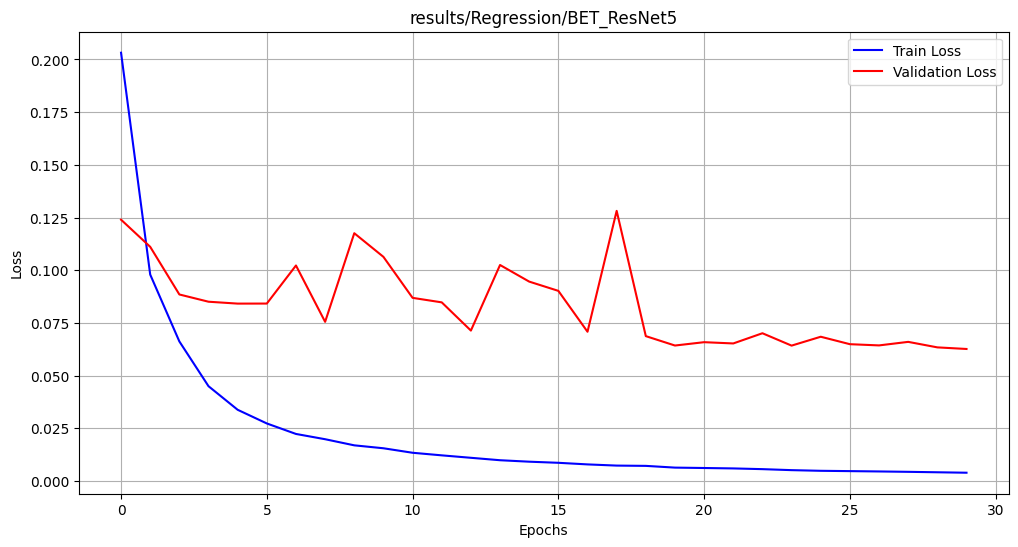

In [5]:
exp = "Regression/BET_ResNet5"
resultsPath = os.path.join("results", exp)

# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)